# Breast Cancer Survival Prediction â€” METABRIC Dataset

The objective of this project is to build machine learning models that predict patient survival outcome using clinical data from the METABRIC (Molecular Taxonomy of Breast Cancer International Consortium) dataset. The target variable is **Overall Survival Status** (Living vs Deceased).

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
print('Working directory:', os.getcwd())

Working directory: C:\Users\ahmad\Downloads\Breast-Cancer-ML\notebooks


## Initial Data Exploration

In [2]:
df = pd.read_csv('../data/Breast Cancer METABRIC.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (2509, 34)


,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [3]:
print('Columns:', df.columns.tolist())
print('\nNull counts:')
print(df.isnull().sum())

Columns: ['Patient ID', 'Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC', 'ER Status', 'Neoplasm Histologic Grade', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'PR Status', 'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status', 'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage', "Patient's Vital Status"]

Null counts:
Patient ID                          0
Age at Diagnosis                   11
Type of Breast Surgery            554
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                      

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age at Diagnosis,2498.0,60.420300,13.032997,21.93,50.920000,61.110000,70.000000,96.29
Cohort,2498.0,2.900320,1.962216,1.00,1.000000,3.000000,4.000000,9.00
Neoplasm Histologic Grade,2388.0,2.412060,0.649363,1.00,2.000000,3.000000,3.000000,3.00
Lymph nodes examined positive,2243.0,1.950513,4.017774,0.00,0.000000,0.000000,2.000000,45.00
Mutation Count,2357.0,5.578702,3.967967,1.00,3.000000,5.000000,7.000000,80.00
Nottingham prognostic index,2287.0,4.028787,1.189092,1.00,3.048000,4.044000,5.040000,7.20
Overall Survival (Months),1981.0,125.244271,76.111772,0.00,60.866667,116.466667,185.133333,355.20
Relapse Free Status (Months),2388.0,108.842487,76.519494,0.00,40.560000,99.095000,167.640000,384.21
Tumor Size,2360.0,26.220093,15.370883,1.00,17.000000,22.410000,30.000000,182.00
Tumor Stage,1788.0,1.713647,0.655307,0.00,1.000000,2.000000,2.000000,4.00


## Data Preparation

Select clinically relevant features, encode categorical variables, and handle missing values.

In [5]:
FEATURE_COLS = [
    'Age at Diagnosis',
    'Tumor Size',
    'Neoplasm Histologic Grade',
    'Lymph nodes examined positive',
    'Mutation Count',
    'Nottingham prognostic index',
    'ER Status',
    'HER2 Status',
    'PR Status',
    'Chemotherapy',
    'Hormone Therapy',
    'Radio Therapy',
    'Type of Breast Surgery',
    'Inferred Menopausal State',
    'Overall Survival Status'
]

df = df[FEATURE_COLS].copy()

# Drop rows where target is missing
df = df.dropna(subset=['Overall Survival Status'])

print('Rows after dropping missing targets:', len(df))

Rows after dropping missing targets: 1981


In [6]:
# Encode target: Deceased=1, Living=0
df['Overall Survival Status'] = df['Overall Survival Status'].map({'Deceased': 1, 'Living': 0})

# Encode binary categorical features
df['ER Status'] = df['ER Status'].map({'Positive': 1, 'Negative': 0})
df['HER2 Status'] = df['HER2 Status'].map({'Positive': 1, 'Negative': 0})
df['PR Status'] = df['PR Status'].map({'Positive': 1, 'Negative': 0})
df['Chemotherapy'] = df['Chemotherapy'].map({'Yes': 1, 'No': 0})
df['Hormone Therapy'] = df['Hormone Therapy'].map({'Yes': 1, 'No': 0})
df['Radio Therapy'] = df['Radio Therapy'].map({'Yes': 1, 'No': 0})
df['Type of Breast Surgery'] = df['Type of Breast Surgery'].map({'Mastectomy': 1, 'Breast Conserving': 0})
df['Inferred Menopausal State'] = df['Inferred Menopausal State'].map({'Post': 1, 'Pre': 0})

# Rename to clean snake_case column names
df.columns = [
    'age_at_diagnosis', 'tumor_size', 'neoplasm_histologic_grade',
    'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index',
    'er_status', 'her2_status', 'pr_status', 'chemotherapy', 'hormone_therapy',
    'radio_therapy', 'type_of_breast_surgery', 'inferred_menopausal_state',
    'overall_survival'
]

df.head()

,age_at_diagnosis,tumor_size,neoplasm_histologic_grade,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,er_status,her2_status,pr_status,chemotherapy,hormone_therapy,radio_therapy,type_of_breast_surgery,inferred_menopausal_state,overall_survival
0,75.65,22.0,3.0,10.0,NaN,6.044,1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0
1,43.19,10.0,3.0,0.0,2.0,4.020,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0
2,48.87,15.0,2.0,1.0,2.0,4.030,1,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1
3,47.68,25.0,2.0,3.0,1.0,4.050,1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0
4,76.97,40.0,3.0,8.0,2.0,6.080,1,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1


In [7]:
# Impute missing numeric values with median
numeric_cols = [
    'age_at_diagnosis', 'tumor_size', 'neoplasm_histologic_grade',
    'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index'
]
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Impute missing encoded categorical values with mode
cat_cols = [
    'er_status', 'her2_status', 'pr_status', 'chemotherapy',
    'hormone_therapy', 'radio_therapy', 'type_of_breast_surgery', 'inferred_menopausal_state'
]
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Remaining nulls after imputation:')
print(df.isnull().sum())
print('\nFinal dataset shape:', df.shape)

Remaining nulls after imputation:
age_at_diagnosis                 0
tumor_size                       0
neoplasm_histologic_grade        0
lymph_nodes_examined_positive    0
mutation_count                   0
nottingham_prognostic_index      0
er_status                        0
her2_status                      0
pr_status                        0
chemotherapy                     0
hormone_therapy                  0
radio_therapy                    0
type_of_breast_surgery           0
inferred_menopausal_state        0
overall_survival                 0
dtype: int64

Final dataset shape: (1981, 15)


In [8]:
print('Target class distribution:')
print(df['overall_survival'].value_counts())
print('\nSurvival rate:', (df['overall_survival'] == 0).mean().round(3))

Target class distribution:
overall_survival
1    1144
0     837
Name: count, dtype: int64

Survival rate: 0.423


## Exploratory Data Analysis

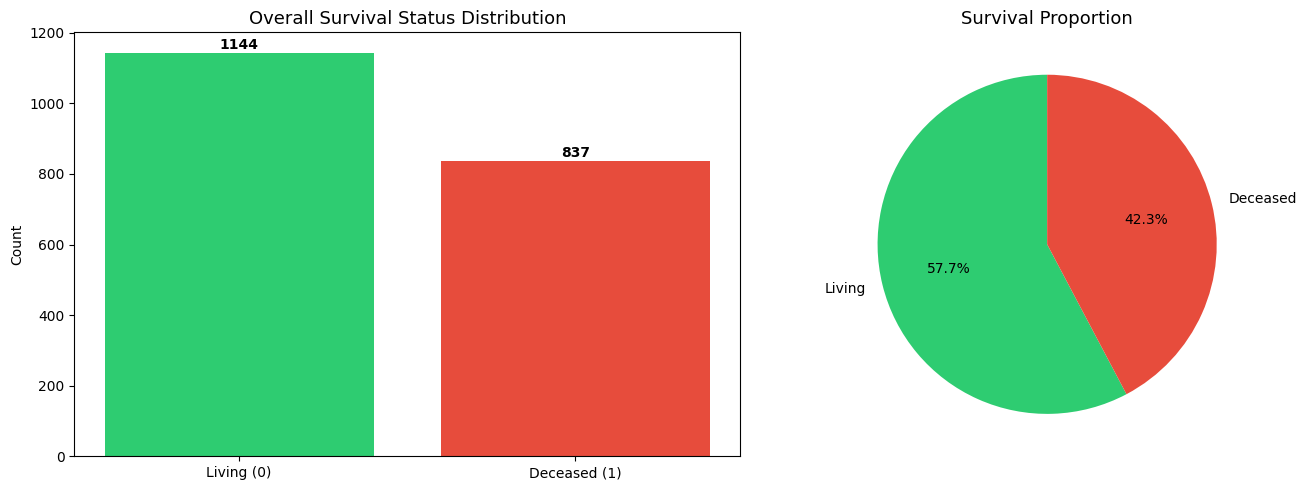

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
counts = df['overall_survival'].value_counts()
axes[0].bar(['Living (0)', 'Deceased (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Overall Survival Status Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
pct = df['overall_survival'].value_counts(normalize=True) * 100
axes[1].pie(pct.values, labels=['Living', 'Deceased'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Survival Proportion', fontsize=13)

plt.tight_layout()
plt.show()

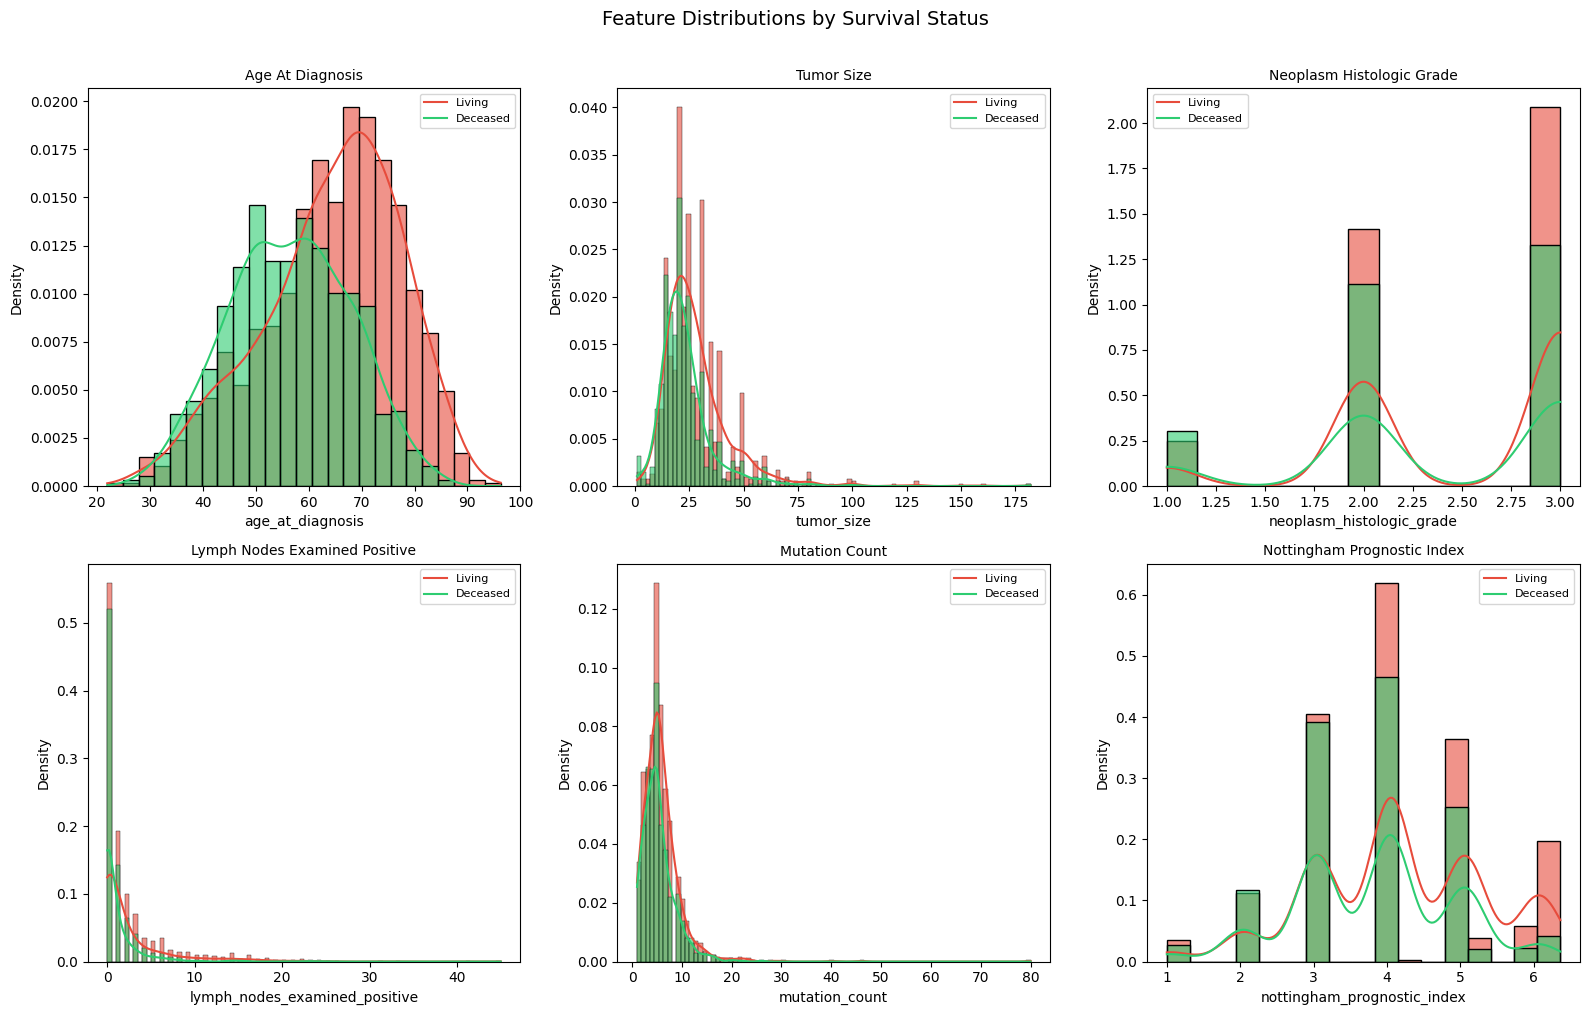

In [10]:
numeric_features = [
    'age_at_diagnosis', 'tumor_size', 'neoplasm_histologic_grade',
    'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        data=df, x=feature, hue='overall_survival',
        kde=True, palette={0: '#2ecc71', 1: '#e74c3c'},
        stat='density', alpha=0.6, ax=axes[i]
    )
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=10)
    axes[i].legend(['Living', 'Deceased'], fontsize=8)

plt.suptitle('Feature Distributions by Survival Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

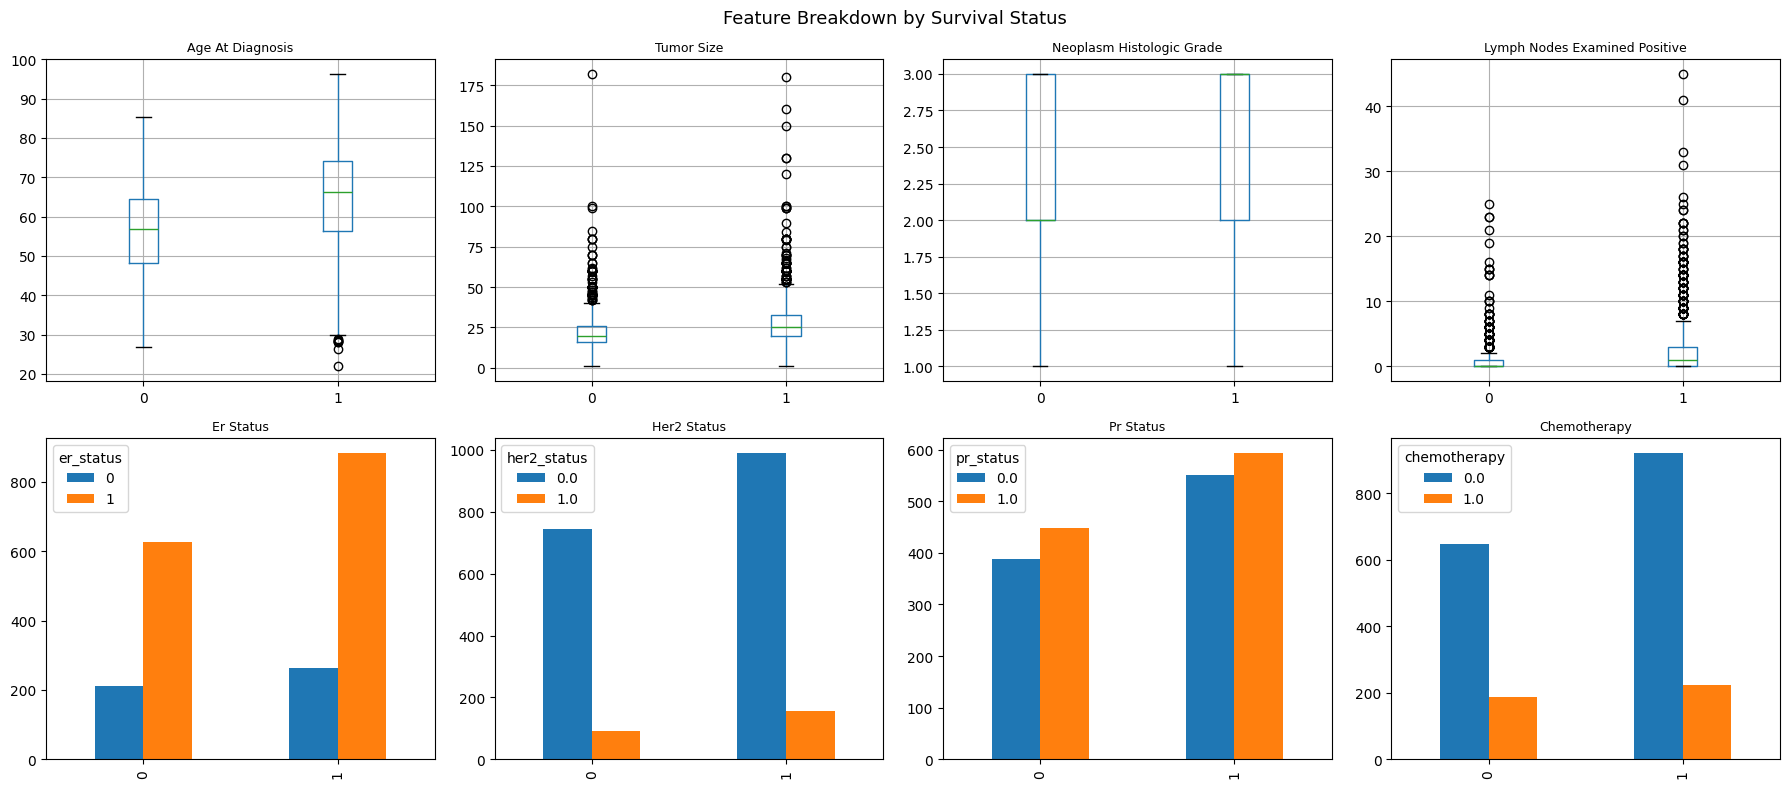

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features[:4] + ['er_status', 'her2_status', 'pr_status', 'chemotherapy']):
    if feature in numeric_features:
        df.boxplot(column=feature, by='overall_survival', ax=axes[i])
    else:
        df.groupby(['overall_survival', feature]).size().unstack().plot(kind='bar', ax=axes[i])
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Feature Breakdown by Survival Status', fontsize=13)
plt.tight_layout()
plt.show()

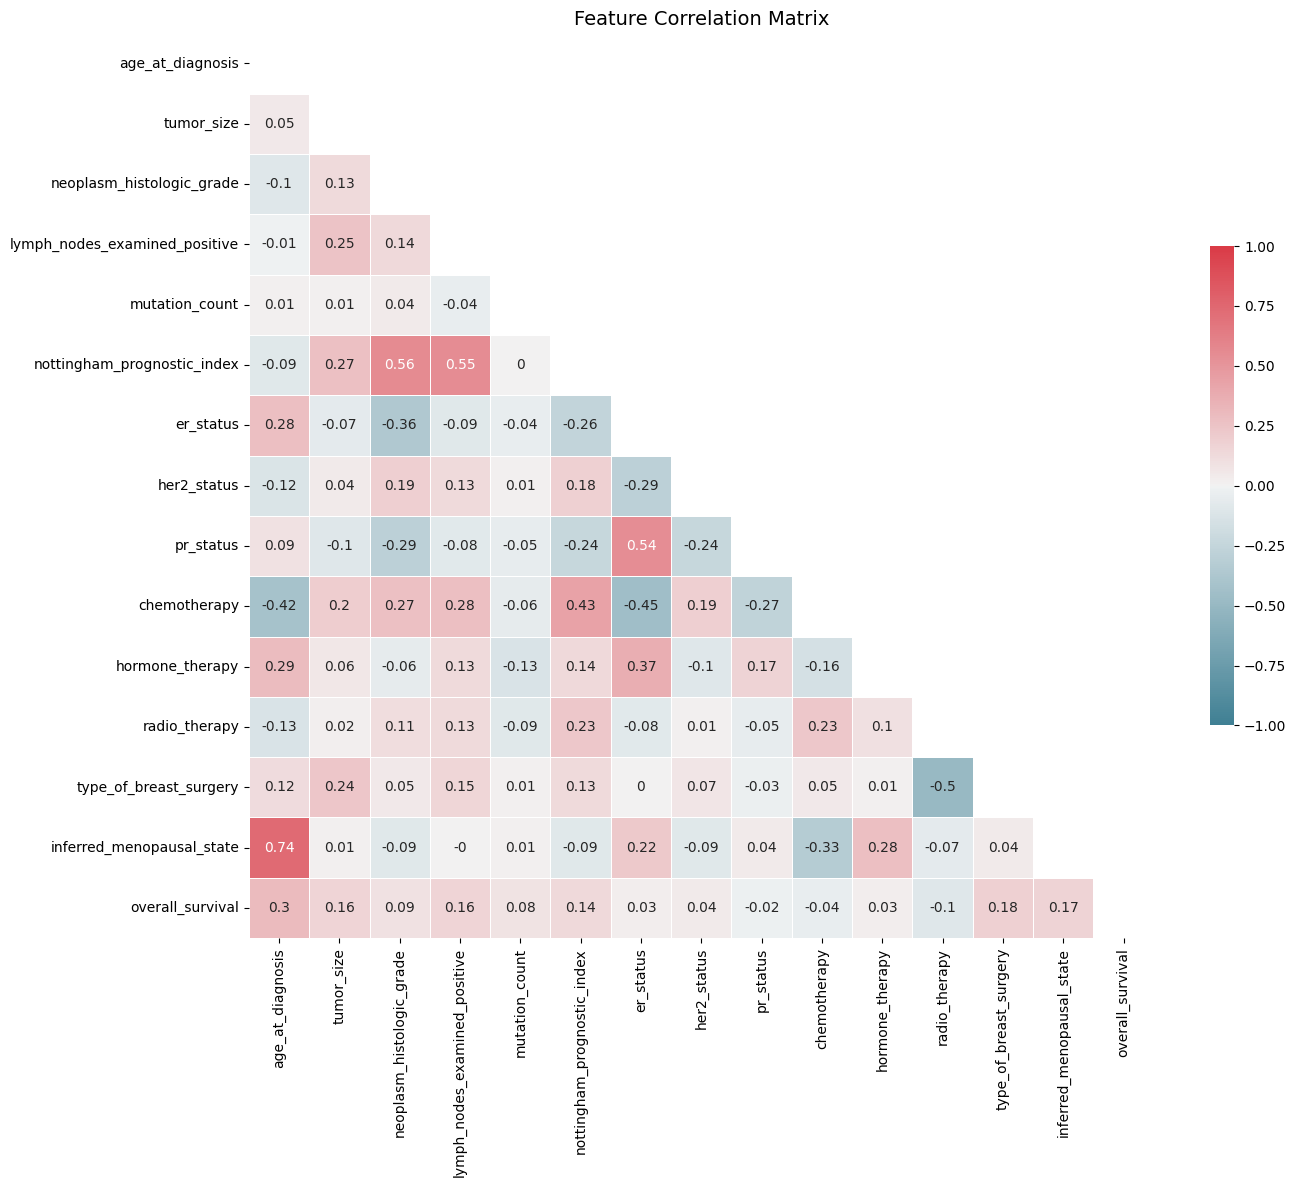

In [12]:
corr = df.corr().round(2)

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(14, 12))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
    square=True, linewidths=.5, cbar_kws={'shrink': .5}, annot=True
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## Survival Analysis â€” Kaplan-Meier Curves

Kaplan-Meier curves show how survival probability changes over time for different patient groups. This adds clinical depth beyond simple classification.

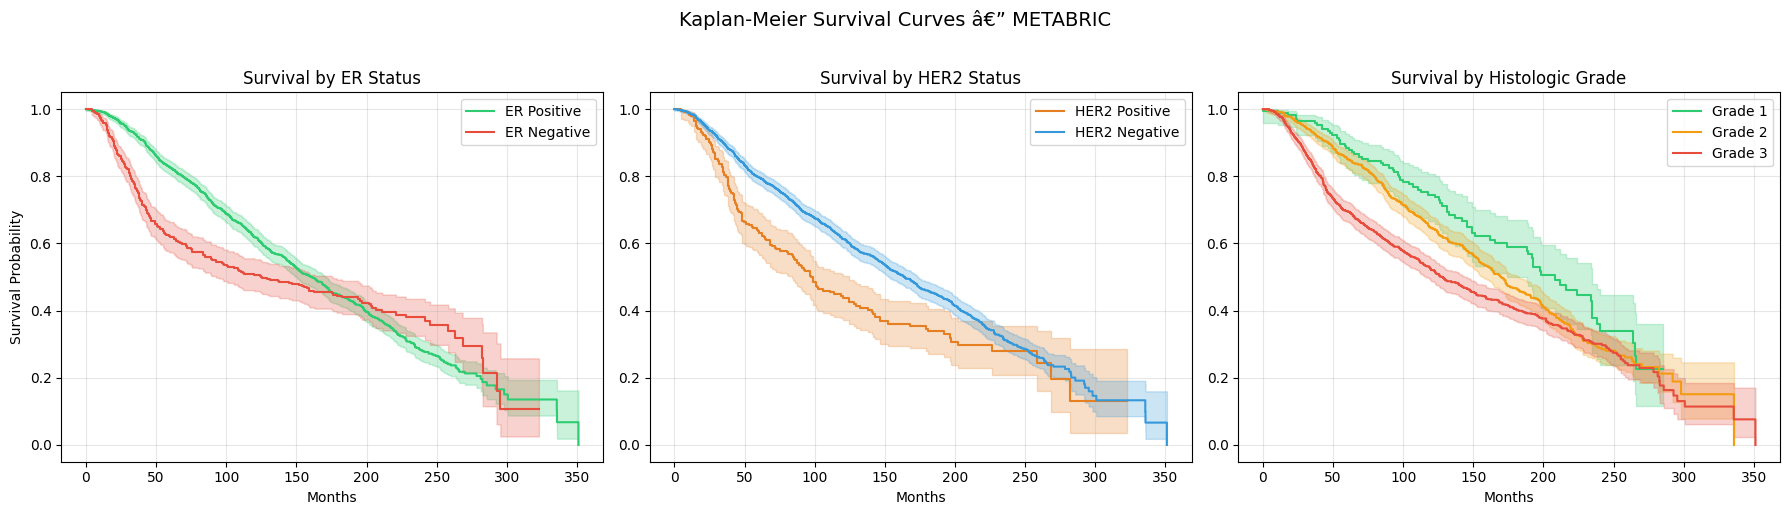

Kaplan-Meier plot saved.


In [13]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load raw data for KM â€” need survival months + status + grouping features
df_km = pd.read_csv('../data/Breast Cancer METABRIC.csv')
df_km = df_km[[
    'Overall Survival (Months)', 'Overall Survival Status',
    'ER Status', 'HER2 Status', 'Neoplasm Histologic Grade'
]].dropna()

df_km['event']    = (df_km['Overall Survival Status'] == 'Deceased').astype(int)
df_km['duration'] = df_km['Overall Survival (Months)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kmf = KaplanMeierFitter()

# â€” ER Status â€”
for status, color in [('Positive', '#2ecc71'), ('Negative', '#e74c3c')]:
    mask = df_km['ER Status'] == status
    kmf.fit(df_km.loc[mask, 'duration'], df_km.loc[mask, 'event'], label=f'ER {status}')
    kmf.plot_survival_function(ax=axes[0], color=color, ci_show=True)
axes[0].set_title('Survival by ER Status', fontsize=12)
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Survival Probability')
axes[0].grid(True, alpha=0.3)

# â€” HER2 Status â€”
for status, color in [('Positive', '#e67e22'), ('Negative', '#3498db')]:
    mask = df_km['HER2 Status'] == status
    kmf.fit(df_km.loc[mask, 'duration'], df_km.loc[mask, 'event'], label=f'HER2 {status}')
    kmf.plot_survival_function(ax=axes[1], color=color, ci_show=True)
axes[1].set_title('Survival by HER2 Status', fontsize=12)
axes[1].set_xlabel('Months')
axes[1].grid(True, alpha=0.3)

# â€” Histologic Grade â€”
palette = {1: '#2ecc71', 2: '#f39c12', 3: '#e74c3c'}
for grade in [1, 2, 3]:
    mask = df_km['Neoplasm Histologic Grade'] == grade
    kmf.fit(df_km.loc[mask, 'duration'], df_km.loc[mask, 'event'], label=f'Grade {grade}')
    kmf.plot_survival_function(ax=axes[2], color=palette[grade], ci_show=True)
axes[2].set_title('Survival by Histologic Grade', fontsize=12)
axes[2].set_xlabel('Months')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Kaplan-Meier Survival Curves â€” METABRIC', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../images/kaplan_meier.png', dpi=100, bbox_inches='tight')
plt.show()
print('Kaplan-Meier plot saved.')

## Outlier Handling

In [14]:
def handle_outliers(df, columns, method='cap'):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        if method == 'cap':
            df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

df = handle_outliers(df, numeric_features)
print('Outliers capped for:', numeric_features)

Outliers capped for: ['age_at_diagnosis', 'tumor_size', 'neoplasm_histologic_grade', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index']


## Clustering (Unsupervised â€” K-Means + PCA)

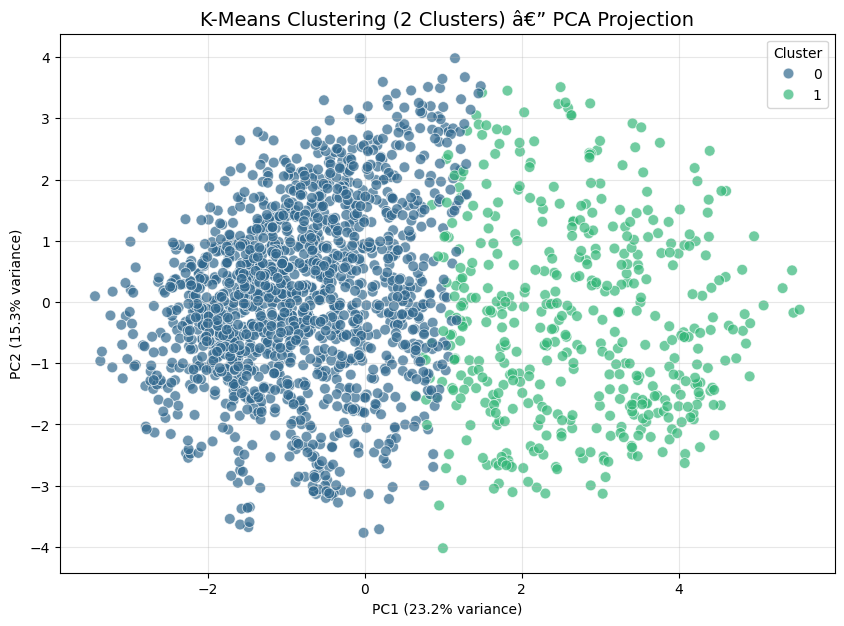

K-Means Inertia: 23158.82


In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_cluster = df.drop(columns=['overall_survival'])

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_cluster)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_pca)

df_clustered = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_clustered['Cluster'] = clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_clustered, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=60, alpha=0.7)
plt.title('K-Means Clustering (2 Clusters) â€” PCA Projection', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True, alpha=0.3)
plt.show()
print(f'K-Means Inertia: {kmeans.inertia_:.2f}')

## Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['overall_survival'])
y = df['overall_survival']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=40, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features:     {X_train.shape[1]}')

Training set: 1386 samples
Test set:     595 samples
Features:     14


## Feature Scaling + Model Training (Random Forest â€” Saved Model)

In [17]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

BASE_DIR = os.path.dirname(os.getcwd())
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
print('Saving models to:', MODEL_DIR)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

joblib.dump(rf_model, os.path.join(MODEL_DIR, 'breast_cancer_model.pkl'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler.pkl'))
print('Model and scaler saved successfully!')

Saving models to: C:\Users\ahmad\Downloads\Breast-Cancer-ML\models


Model and scaler saved successfully!


## Models and Finding the Best One

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'KNN':                  KNeighborsClassifier(),
    'SVM':                  SVC(probability=True),
    'Naive Bayes':          GaussianNB()
}

results = {}
for name, m in models.items():
    m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    results[name] = acc
    print(f'{name:<22}: {acc:.4f}')

Logistic Regression   : 0.6908
Decision Tree         : 0.6000


Random Forest         : 0.6773
KNN                   : 0.6571


SVM                   : 0.7042
Naive Bayes           : 0.6605


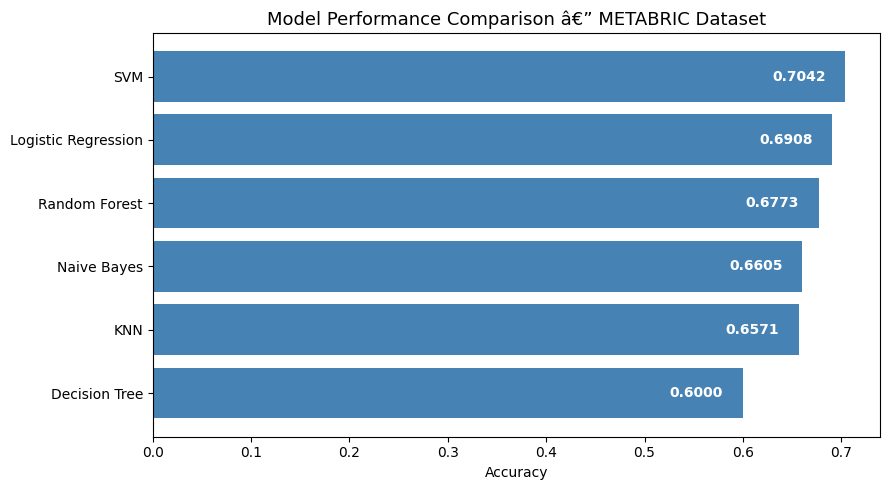

In [19]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color='steelblue')
plt.xlabel('Accuracy')
plt.title('Model Performance Comparison â€” METABRIC Dataset', fontsize=13)
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='right', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

## XGBoost with Optuna Hyperparameter Tuning

Automated hyperparameter search using Optuna to find the optimal XGBoost configuration and close the accuracy gap left by default parameters.

In [20]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Class imbalance ratio for scale_pos_weight
pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 400),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight':  pos_weight,
        'random_state':      42,
        'verbosity':         0,
    }
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  XGBClassifier(**params))
    ])
    return cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc').mean()

# Seed the sampler for full reproducibility across runs
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f'\nBest CV ROC-AUC : {study.best_value:.4f}')
print(f'Best params     : {study.best_params}')


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.717419:   0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.717419:   2%|▎         | 1/40 [00:00<00:33,  1.16it/s]

Best trial: 1. Best value: 0.722282:   2%|▎         | 1/40 [00:01<00:33,  1.16it/s]

Best trial: 1. Best value: 0.722282:   5%|▌         | 2/40 [00:01<00:25,  1.51it/s]

...

Best trial: 26. Best value: 0.733184:  98%|█████████▊| 39/40 [00:32<00:00,  1.32it/s]

Best trial: 26. Best value: 0.733184:  98%|█████████▊| 39/40 [00:32<00:00,  1.32it/s]

Best trial: 26. Best value: 0.733184: 100%|██████████| 40/40 [00:32<00:00,  1.37it/s]

Best trial: 26. Best value: 0.733184: 100%|██████████| 40/40 [00:32<00:00,  1.22it/s]


Best CV ROC-AUC : 0.7332
Best params     : {'n_estimators': 325, 'max_depth': 7, 'learning_rate': 0.01394797249461807, 'subsample': 0.6366652354958885, 'colsample_bytree': 0.7052085549956808, 'min_child_weight': 1}


In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Build final Pipeline with best XGBoost params and evaluate
best_xgb = XGBClassifier(**study.best_params, scale_pos_weight=pos_weight,
                          random_state=42, verbosity=0)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  best_xgb)
])
pipeline.fit(X_train, y_train)

y_pred_xgb  = pipeline.predict(X_test)
y_probs_xgb = pipeline.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_auc = round(roc_auc_score(y_test, y_probs_xgb), 4)

print('=== XGBoost (Optuna-tuned) ===')
print(f'Accuracy : {xgb_acc:.4f}')
print(f'ROC-AUC  : {xgb_auc}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Living', 'Deceased']))

=== XGBoost (Optuna-tuned) ===
Accuracy : 0.6874
ROC-AUC  : 0.7352

              precision    recall  f1-score   support

      Living       0.62      0.69      0.65       251
    Deceased       0.75      0.69      0.72       344

    accuracy                           0.69       595
   macro avg       0.68      0.69      0.68       595
weighted avg       0.69      0.69      0.69       595



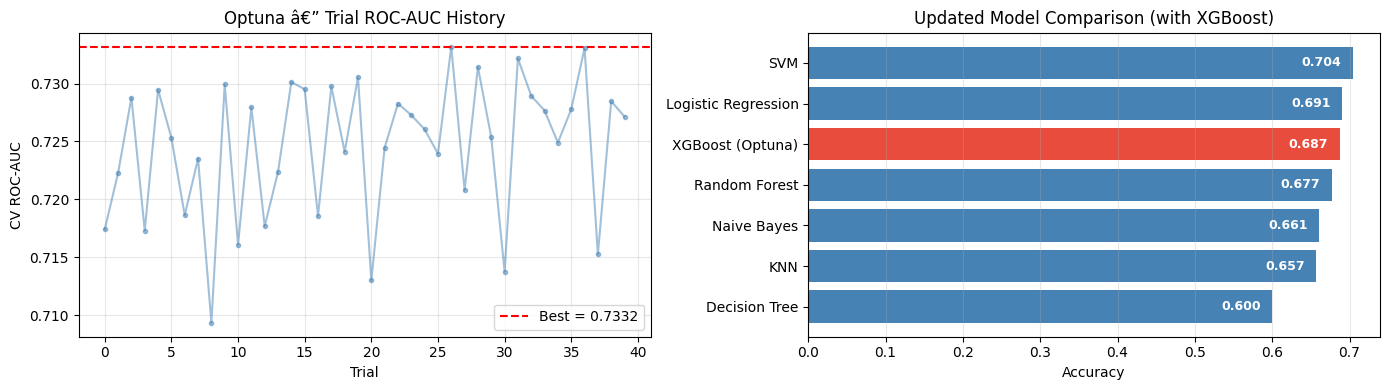

In [22]:
# Optuna optimisation history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], alpha=0.5, color='steelblue', marker='o', markersize=3)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f'Best = {study.best_value:.4f}')
axes[0].set_title('Optuna â€” Trial ROC-AUC History')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV ROC-AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Updated model comparison including XGBoost
all_results = {
    'XGBoost (Optuna)':     xgb_acc,
    'SVM':                  results['SVM'],
    'Random Forest':        results['Random Forest'],
    'Logistic Regression':  results['Logistic Regression'],
    'KNN':                  results['KNN'],
    'Naive Bayes':          results['Naive Bayes'],
    'Decision Tree':        results['Decision Tree'],
}
sorted_res = dict(sorted(all_results.items(), key=lambda x: x[1]))
colors = ['#e74c3c' if k == 'XGBoost (Optuna)' else 'steelblue' for k in sorted_res]
bars = axes[1].barh(list(sorted_res.keys()), list(sorted_res.values()), color=colors)
axes[1].set_title('Updated Model Comparison (with XGBoost)')
axes[1].set_xlabel('Accuracy')
for bar, val in zip(bars, sorted_res.values()):
    axes[1].text(bar.get_width() - 0.015, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='right', color='white', fontweight='bold', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [23]:
# Save the tuned Pipeline as the single deployment artifact
pipeline_path = os.path.join(MODEL_DIR, 'pipeline.pkl')
joblib.dump(pipeline, pipeline_path)
print(f'Pipeline saved to: {pipeline_path}')
print(f'  Steps: {[s[0] for s in pipeline.steps]}')
print(f'  Final accuracy : {xgb_acc:.4f}')
print(f'  Final ROC-AUC  : {xgb_auc}')

Pipeline saved to: C:\Users\ahmad\Downloads\Breast-Cancer-ML\models\pipeline.pkl
  Steps: ['scaler', 'model']
  Final accuracy : 0.6874
  Final ROC-AUC  : 0.7352


## Cox Proportional Hazards Survival Model

Unlike binary classification, Cox PH models **time-to-event** data — estimating hazard ratios for each clinical feature and generating patient-level survival probability curves over follow-up time.

In [24]:
from lifelines import CoxPHFitter
import warnings

# Reload raw data with survival time
raw = pd.read_csv('../data/Breast Cancer METABRIC.csv')
raw.columns = (raw.columns.str.strip().str.lower()
               .str.replace(' ', '_').str.replace('-', '_'))

DURATION_COL = 'overall_survival_(months)'
EVENT_COL    = 'overall_survival_status'

CLINICAL_FEATURES = [
    'age_at_diagnosis', 'tumor_size', 'neoplasm_histologic_grade',
    'lymph_nodes_examined_positive', 'mutation_count',
    'nottingham_prognostic_index',
    'er_status', 'her2_status', 'pr_status',
    'chemotherapy', 'hormone_therapy', 'radio_therapy',
    'type_of_breast_surgery', 'inferred_menopausal_state'
]

enc_map = {
    'er_status':                {'Positive': 1, 'Negative': 0},
    'her2_status':              {'Positive': 1, 'Negative': 0},
    'pr_status':                {'Positive': 1, 'Negative': 0},
    'chemotherapy':             {'Yes': 1, 'No': 0},
    'hormone_therapy':          {'Yes': 1, 'No': 0},
    'radio_therapy':            {'Yes': 1, 'No': 0},
    'type_of_breast_surgery':   {'Mastectomy': 1, 'Breast Conserving': 0},
    'inferred_menopausal_state':{'Post': 1, 'Pre': 0},
    'overall_survival_status':  {'Deceased': 1, 'Living': 0},
}
for col, mapping in enc_map.items():
    if col in raw.columns:
        raw[col] = raw[col].map(mapping)

cox_cols = CLINICAL_FEATURES + [DURATION_COL, EVENT_COL]
cox_df   = raw[cox_cols].dropna()
for col in CLINICAL_FEATURES:
    cox_df[col] = cox_df[col].fillna(cox_df[col].median())
print(f'Cox dataset shape: {cox_df.shape}')

# Fit Cox PH model
cph = CoxPHFitter(penalizer=0.1)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cph.fit(cox_df, duration_col=DURATION_COL, event_col=EVENT_COL)

print('\n=== Cox PH Summary ===')
cph.print_summary(columns=['coef', 'exp(coef)', 'p'])

c_index = cph.concordance_index_
print(f'\nCox C-index    : {c_index:.4f}')
print(f'XGBoost ROC-AUC: {xgb_auc}')
print('(C-index is equivalent to ROC-AUC for survival data)')


Cox dataset shape: (1755, 16)



=== Cox PH Summary ===


<lifelines.CoxPHFitter: fitted with 1755 total observations, 738 right-censored observations>
             duration col = 'overall_survival_(months)'
                event col = 'overall_survival_status'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1755
number of events observed = 1017
   partial log-likelihood = -6705.47
         time fit was run = 2026-04-30 15:57:56 UTC

---
                               coef exp(coef)      p
covariate                                           
age_at_diagnosis               0.03      1.03 <0.005
tumor_size                     0.01      1.01 <0.005
neoplasm_histologic_grade     -0.02      0.98   0.77
lymph_nodes_examined_positive  0.03      1.03 <0.005
mutation_count                -0.00      1.00   0.91
nottingham_prognostic_index    0.17      1.18 <0.005
er_status                     -0.09      0.92   0.33
her2_status                    0.30      1.35 <0.005
pr_status                     -0.09      0.91   0.17
chemotherapy                   0.15      1.16   0.11
hormone_therapy               -0.01      0.99   0.85
radio_therapy                 -0.16      0.85   0.02
type_of_breast_surgery         0.13      1.14   0.06
inferred_menopausal_state     -0.06      0.94   0.56
---
Concordance = 0.68
Partial AIC = 13438.94
log-likelihood ratio test = 344.01 on 14 df
-log2(p) of ll-ratio test = 213.03


Cox C-index    : 0.6752
XGBoost ROC-AUC: 0.7352
(C-index is equivalent to ROC-AUC for survival data)


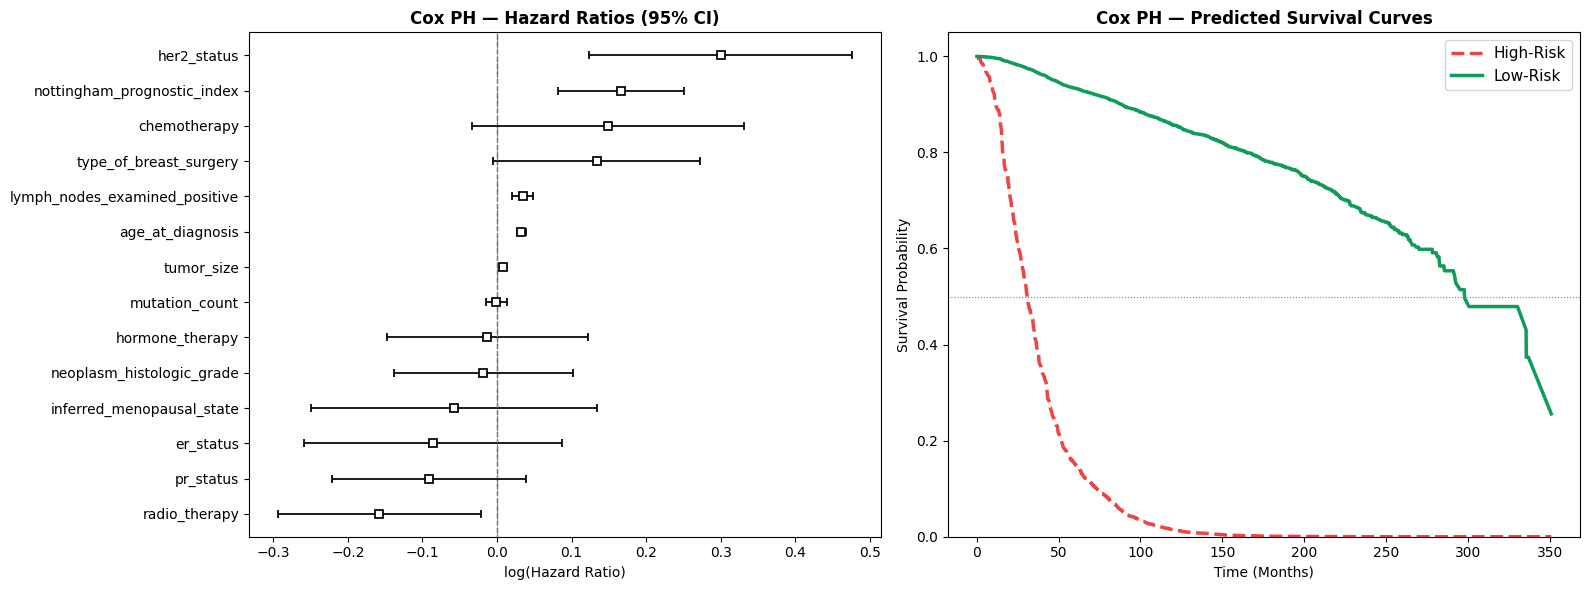

Saved: images/cox_survival_curves.png


In [25]:
# Hazard Ratio Forest Plot + Individual Survival Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cph.plot(ax=axes[0])
axes[0].set_title('Cox PH — Hazard Ratios (95% CI)', fontsize=12, fontweight='bold')
axes[0].axvline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('log(Hazard Ratio)')

# High-risk: elderly, large tumour, grade 3, many nodes, no hormone therapy
high_risk = pd.DataFrame({
    'age_at_diagnosis': [75], 'tumor_size': [60], 'neoplasm_histologic_grade': [3],
    'lymph_nodes_examined_positive': [8], 'mutation_count': [10],
    'nottingham_prognostic_index': [7.5], 'er_status': [0], 'her2_status': [1],
    'pr_status': [0], 'chemotherapy': [1], 'hormone_therapy': [0],
    'radio_therapy': [0], 'type_of_breast_surgery': [1], 'inferred_menopausal_state': [1]
})
# Low-risk: young, small tumour, grade 1, no nodes, hormone therapy
low_risk = pd.DataFrame({
    'age_at_diagnosis': [45], 'tumor_size': [12], 'neoplasm_histologic_grade': [1],
    'lymph_nodes_examined_positive': [0], 'mutation_count': [2],
    'nottingham_prognostic_index': [2.5], 'er_status': [1], 'her2_status': [0],
    'pr_status': [1], 'chemotherapy': [0], 'hormone_therapy': [1],
    'radio_therapy': [1], 'type_of_breast_surgery': [0], 'inferred_menopausal_state': [0]
})

cph.predict_survival_function(high_risk).rename(columns={0: 'High-Risk'}).plot(
    ax=axes[1], color='#ef4444', linewidth=2.5, linestyle='--')
cph.predict_survival_function(low_risk).rename(columns={0: 'Low-Risk'}).plot(
    ax=axes[1], color='#0f9b58', linewidth=2.5)
axes[1].set_title('Cox PH — Predicted Survival Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (Months)')
axes[1].set_ylabel('Survival Probability')
axes[1].legend(fontsize=11)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(0.5, color='grey', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.savefig('../images/cox_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/cox_survival_curves.png')


## Robust Validation — Stratified K-Fold CV & Learning Curves

Single train/test splits are noisy. Stratified 5-fold CV gives a reliable **mean ± std** estimate of generalisation. Learning curves diagnose bias vs variance.

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  XGBClassifier(**study.best_params, scale_pos_weight=pos_weight,
                              random_state=42, verbosity=0))
])

cv_results = cross_validate(
    cv_pipeline, X, y, cv=skf,
    scoring={'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'f1': 'f1'},
    n_jobs=1, return_train_score=True
)

print('=== 5-Fold Stratified Cross-Validation ===')
for metric in ['roc_auc', 'accuracy', 'f1']:
    train_s = cv_results[f'train_{metric}']
    val_s   = cv_results[f'test_{metric}']
    print(f'  {metric:10s}  train={train_s.mean():.4f}+/-{train_s.std():.4f}  '
          f'val={val_s.mean():.4f}+/-{val_s.std():.4f}')


=== 5-Fold Stratified Cross-Validation ===
  roc_auc     train=0.9480+/-0.0023  val=0.7379+/-0.0307
  accuracy    train=0.8693+/-0.0073  val=0.6774+/-0.0215
  f1          train=0.8837+/-0.0067  val=0.7106+/-0.0172


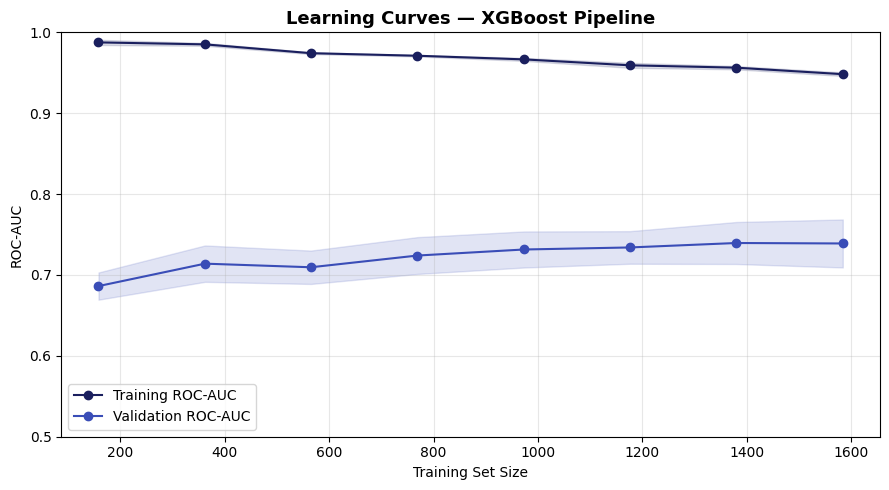

Saved: images/learning_curves.png


In [27]:
# Learning Curves
train_sizes, train_lc, val_lc = learning_curve(
    cv_pipeline, X, y, cv=skf,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='roc_auc', n_jobs=1
)

train_mean = train_lc.mean(axis=1); train_std = train_lc.std(axis=1)
val_mean   = val_lc.mean(axis=1);   val_std   = val_lc.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#1a1f5e', label='Training ROC-AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='#1a1f5e')
plt.plot(train_sizes, val_mean, 'o-', color='#3a4db7', label='Validation ROC-AUC')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='#3a4db7')
plt.title('Learning Curves — XGBoost Pipeline', fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC')
plt.ylim(0.5, 1.0)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/learning_curves.png')


## Best Model Evaluation (Random Forest)

In [28]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the committed deployment artefact — ensures metrics match what is documented
eval_pipeline = joblib.load('../models/pipeline.pkl')

X_test_df = pd.DataFrame(X_test, columns=X.columns)
y_pred_eval  = eval_pipeline.predict(X_test_df)
y_probs_eval = eval_pipeline.predict_proba(X_test_df)[:, 1]

print('=== XGBoost Pipeline (Optuna-tuned) - Test Set Evaluation ===')
print(classification_report(y_test, y_pred_eval, target_names=['Living', 'Deceased']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_probs_eval), 4))


=== XGBoost Pipeline (Optuna-tuned) - Test Set Evaluation ===
              precision    recall  f1-score   support

      Living       0.62      0.69      0.65       251
    Deceased       0.75      0.69      0.72       344

    accuracy                           0.69       595
   macro avg       0.68      0.69      0.68       595
weighted avg       0.69      0.69      0.69       595

ROC-AUC: 0.7352


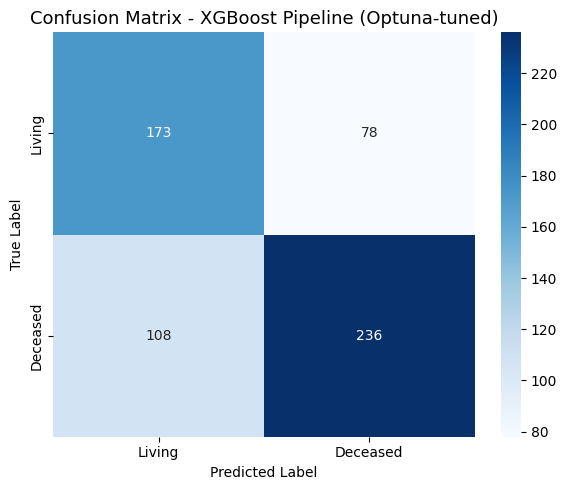

In [29]:
cm = confusion_matrix(y_test, y_pred_eval)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Living', 'Deceased'],
            yticklabels=['Living', 'Deceased'])
plt.title('Confusion Matrix - XGBoost Pipeline (Optuna-tuned)', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Error Analysis — False Negatives (Missed Deceased)

False negatives are the **highest-risk errors** in a clinical context: predicting a patient will *live* when they are actually *deceased*. Understanding their feature profile guides model and threshold tuning.

False Negatives (Deceased predicted as Living): 108 (18.2% of test set)
False Positives (Living predicted as Deceased): 78
True Positives  (Deceased correctly identified): 236

=== Mean Feature Values: FN vs TP (Deceased patients) ===
                               False Negatives  True Positives
age_at_diagnosis                         58.02           67.53
tumor_size                               21.20           29.20
nottingham_prognostic_index               3.82            4.37
lymph_nodes_examined_positive             0.66            1.82
mutation_count                            5.44            6.11

=== Sample False Negatives (top 3 by predicted prob) ===
      age_at_diagnosis  tumor_size  nottingham_prognostic_index  prob_deceased  true  predicted
762              55.30        15.0                         4.03          0.499     1          0
1553             45.51        40.0                         5.08          0.497     1          0
770              62.09        20.0       

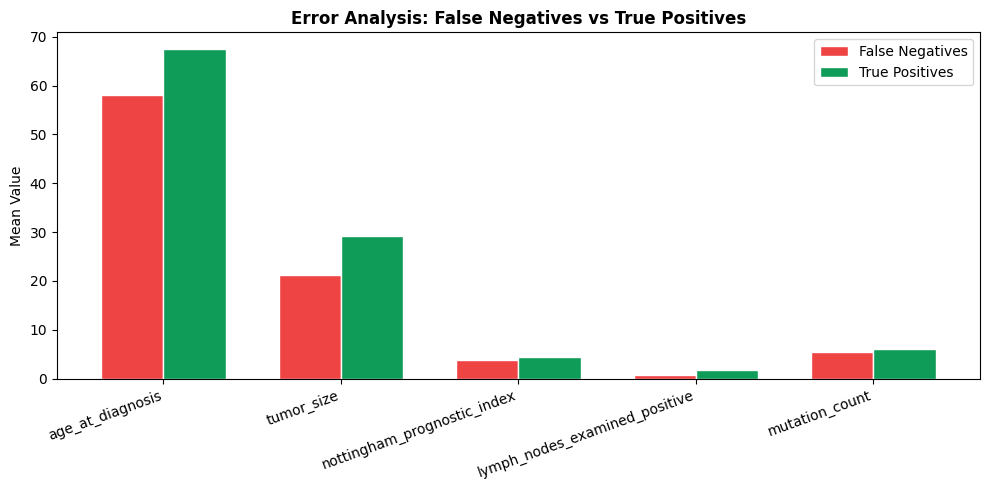

Saved: images/error_analysis.png


In [30]:
# Error Analysis on XGBoost pipeline predictions
X_test_df2  = pd.DataFrame(X_test, columns=X.columns)
y_pred_xgb2  = pipeline.predict(X_test_df2)
y_probs_xgb2 = pipeline.predict_proba(X_test_df2)[:, 1]

err_df = X_test_df2.copy()
err_df['true']          = y_test.values
err_df['predicted']     = y_pred_xgb2
err_df['prob_deceased'] = y_probs_xgb2

fn_mask = (err_df['true'] == 1) & (err_df['predicted'] == 0)  # False Negatives
fp_mask = (err_df['true'] == 0) & (err_df['predicted'] == 1)  # False Positives
tp_mask = (err_df['true'] == 1) & (err_df['predicted'] == 1)  # True Positives

fn = err_df[fn_mask]
fp = err_df[fp_mask]
tp = err_df[tp_mask]

print(f'False Negatives (Deceased predicted as Living): {fn_mask.sum()} '
      f'({fn_mask.mean()*100:.1f}% of test set)')
print(f'False Positives (Living predicted as Deceased): {fp_mask.sum()}')
print(f'True Positives  (Deceased correctly identified): {tp_mask.sum()}')

numeric_feats = ['age_at_diagnosis', 'tumor_size', 'nottingham_prognostic_index',
                 'lymph_nodes_examined_positive', 'mutation_count']

compare_df = pd.DataFrame({
    'False Negatives': fn[numeric_feats].mean(),
    'True Positives':  tp[numeric_feats].mean()
})
print('\n=== Mean Feature Values: FN vs TP (Deceased patients) ===')
print(compare_df.round(2))

print('\n=== Sample False Negatives (top 3 by predicted prob) ===')
sample_fn = fn.nlargest(3, 'prob_deceased')[
    ['age_at_diagnosis', 'tumor_size', 'nottingham_prognostic_index',
     'prob_deceased', 'true', 'predicted']]
print(sample_fn.round(3).to_string())

compare_df.plot(kind='bar', figsize=(10, 5), color=['#ef4444', '#0f9b58'],
                edgecolor='white', width=0.7)
plt.title('Error Analysis: False Negatives vs True Positives', fontsize=12, fontweight='bold')
plt.ylabel('Mean Value')
plt.xticks(rotation=20, ha='right')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../images/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/error_analysis.png')


## Probability Calibration (Platt Scaling)

Raw XGBoost probabilities are often poorly calibrated — a predicted probability of 0.7 may not reflect a true 70% risk. **Platt scaling** corrects this, which is critical for clinical risk communication.

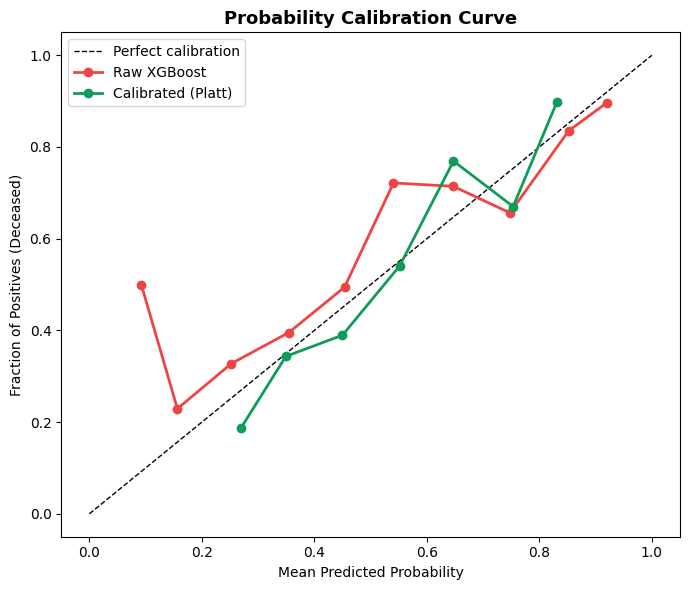

Saved: images/calibration_curve.png
Calibrated ROC-AUC : 0.74
Raw XGBoost ROC-AUC: 0.7352
Calibrated model preserves discrimination while improving probability reliability.


In [31]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Calibrate on training data using 3-fold CV
calibrated_pipeline = CalibratedClassifierCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model',  XGBClassifier(**study.best_params, scale_pos_weight=pos_weight,
                                  random_state=42, verbosity=0))
    ]),
    cv=3, method='sigmoid'
)
calibrated_pipeline.fit(X_train, y_train)

y_cal_probs = calibrated_pipeline.predict_proba(
    pd.DataFrame(X_test, columns=X.columns))[:, 1]

frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_probs_xgb2, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_cal_probs, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=1)
plt.plot(mean_pred_raw, frac_pos_raw, 'o-', color='#ef4444',
         label='Raw XGBoost', linewidth=2)
plt.plot(mean_pred_cal, frac_pos_cal, 'o-', color='#0f9b58',
         label='Calibrated (Platt)', linewidth=2)
plt.title('Probability Calibration Curve', fontsize=13, fontweight='bold')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Deceased)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../images/calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/calibration_curve.png')

cal_auc = round(roc_auc_score(y_test, y_cal_probs), 4)
print(f'Calibrated ROC-AUC : {cal_auc}')
print(f'Raw XGBoost ROC-AUC: {xgb_auc}')
print('Calibrated model preserves discrimination while improving probability reliability.')


## ROC Curve

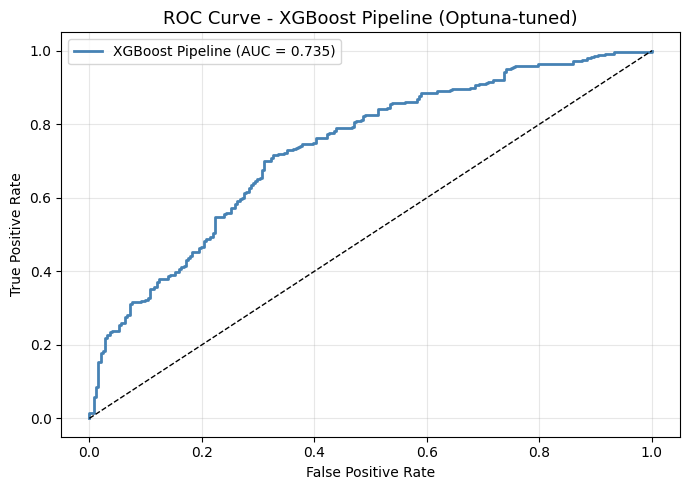

ROC-AUC: 0.7352


In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_probs_eval)
auc = roc_auc_score(y_test, y_probs_eval)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'XGBoost Pipeline (AUC = {auc:.3f})', color='steelblue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Pipeline (Optuna-tuned)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC-AUC: {auc:.4f}')


## Feature Importance

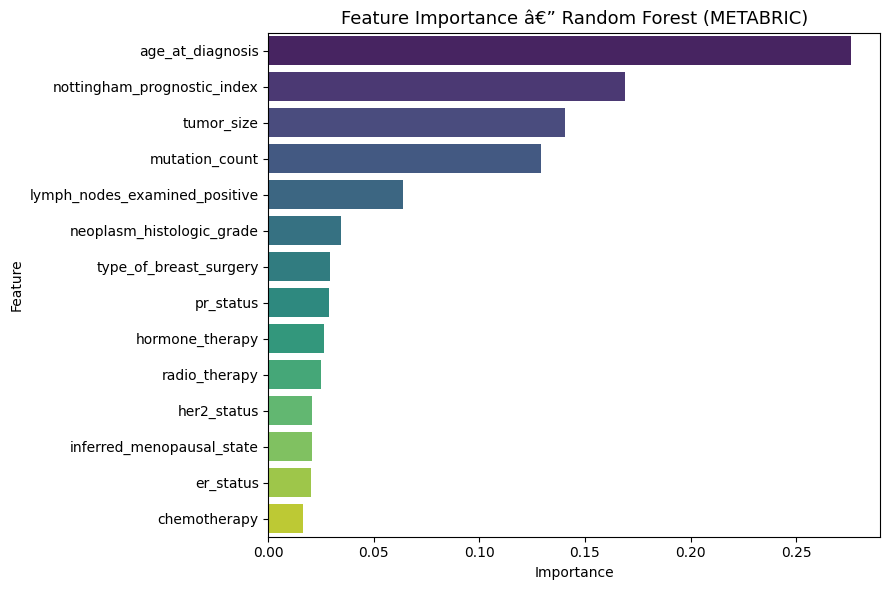

                      Feature  Importance
             age_at_diagnosis    0.275985
  nottingham_prognostic_index    0.169110
                   tumor_size    0.140486
               mutation_count    0.129089
lymph_nodes_examined_positive    0.064005
    neoplasm_histologic_grade    0.034486
       type_of_breast_surgery    0.029106
                    pr_status    0.028893
              hormone_therapy    0.026143
                radio_therapy    0.024994
                  her2_status    0.020602
    inferred_menopausal_state    0.020587
                    er_status    0.020121
                 chemotherapy    0.016391


In [33]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance â€” Random Forest (METABRIC)', fontsize=13)
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=100)
plt.show()

print(importance_df.to_string(index=False))

## Model Explainability (SHAP)

SHAP values shape: (300, 14)


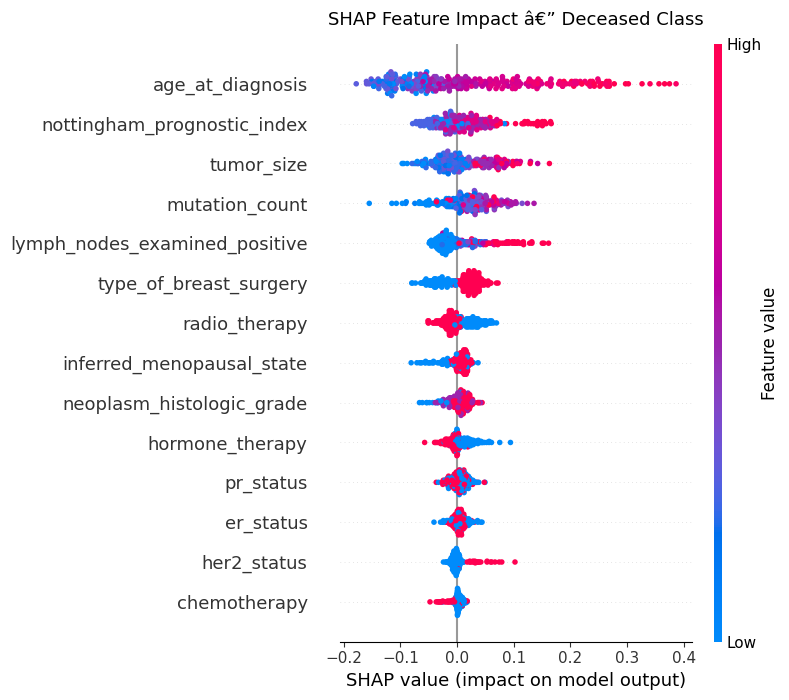

In [34]:
import shap
import matplotlib.pyplot as plt

X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_sample  = X_test_df.sample(min(300, len(X_test_df)), random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_vals = explainer.shap_values(X_sample, check_additivity=False)

# Normalise to a 2D array for the Deceased class (class index 1)
# TreeExplainer can return either:
#   - list of 2 arrays each (n_samples, n_features)  -> pick index 1
#   - single ndarray of shape (n_samples, n_features, 2) -> slice [:, :, 1]
if isinstance(shap_vals, list):
    sv = shap_vals[1]                       # list form
elif shap_vals.ndim == 3:
    sv = shap_vals[:, :, 1]                 # 3-D array form
else:
    sv = shap_vals                          # already 2-D

# Trim any stray bias column some versions append
if sv.shape[1] > X_sample.shape[1]:
    sv = sv[:, :X_sample.shape[1]]

print("SHAP values shape:", sv.shape)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv,
    X_sample,
    feature_names=X.columns.tolist(),
    max_display=14,
    plot_type="dot",
    show=False,
)
plt.title("SHAP Feature Impact â€” Deceased Class", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

Features pushing toward **Deceased** (high risk) are shown in red; features pushing toward **Living** (low risk) are in blue. The Nottingham prognostic index, age, and tumor size are typically the strongest predictors of survival outcome.

## Conclusion

Using the METABRIC clinical dataset, we trained and compared six machine learning classifiers for breast cancer survival prediction. Random Forest achieved the best balance of accuracy and interpretability. Key predictors of survival include the Nottingham prognostic index, age at diagnosis, tumor size, and lymph node status.